# Plant Disease Prediction

## Importing Dataset

Dataset Link: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset

## Importing libraries

In [60]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

## Data Preprocessing

### Training Image preprocessing

In [61]:
# Caminho absoluto da pasta do dataset no seu PC
base_path = r"C:\Users\SRV\Projeto_Agrcultura_De_Precisao\Plant_Disease_Prediction\dataset\New Plant Diseases Dataset(Augmented)"
train_dir = os.path.join(base_path, "train")

# Verifica se o diretório existe
print("Train dir existe?", os.path.exists(train_dir))

# Carrega o dataset
training_set = tf.keras.utils.image_dataset_from_directory(
    train_dir,             # <- caminho absoluto agora
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)


Train dir existe? True
Found 70295 files belonging to 38 classes.


### Validation Image Preprocessing

In [62]:
# Caminho base do dataset
base_path = r"C:\Users\SRV\Projeto_Agrcultura_De_Precisao\Plant_Disease_Prediction\dataset\New Plant Diseases Dataset(Augmented)"
valid_dir = os.path.join(base_path, "valid")

# Verifica se o diretório existe
print("Valid dir existe?", os.path.exists(valid_dir))

# Carrega o dataset de validação
validation_set = tf.keras.utils.image_dataset_from_directory(
    valid_dir,             # <- caminho absoluto agora
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)


Valid dir existe? True
Found 17572 files belonging to 38 classes.


#### To avoid Overshooting Loss function
1. Choose small learning rate default 0.001 here we have taken 0.0001
2. There may be chance of underfitting so increase number of neuron
3. Add more Convolutional Layer to extract more feature from images there may be possibilty that model unable to capture relevant feature or model is confusing due to lack of feature so feed with more feature

## Building Or Loading Existing Model

In [ ]:
import tensorflow as tf
from tensorflow import keras
import os

# Caminho onde o modelo salvo será procurado
model_path = "trained_plant_disease_model.keras"

# Verifica se já existe um modelo salvo
if os.path.exists(model_path):
    resposta = input("Modelo existente encontrado! Deseja continuar o treinamento anterior? (s/n): ").strip().lower()
    
    if resposta == 's':
        print("Carregando o modelo existente...")
        cnn = keras.models.load_model(model_path)
    else:
        print("Criando um novo modelo...")
        cnn = tf.keras.models.Sequential()
else:
    print("Nenhum modelo existente encontrado. Criando novo modelo...")
    cnn = tf.keras.models.Sequential()

# Se o modelo estiver sendo criado do zero, definimos as camadas
if not os.path.exists(model_path) or resposta != 's':
    ### Building Convolution Layers
    cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, padding='same', activation='relu', input_shape=[128,128,3]))
    cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu'))
    cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

    cnn.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
    cnn.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3, activation='relu'))
    cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

    cnn.add(tf.keras.layers.Conv2D(filters=128, kernel_size=3, padding='same', activation='relu'))
    cnn.add(tf.keras.layers.Conv2D(filters=128, kernel_size=3, activation='relu'))
    cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

    cnn.add(tf.keras.layers.Conv2D(filters=256, kernel_size=3, padding='same', activation='relu'))
    cnn.add(tf.keras.layers.Conv2D(filters=256, kernel_size=3, activation='relu'))
    cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

    cnn.add(tf.keras.layers.Conv2D(filters=512, kernel_size=3, padding='same', activation='relu'))
    cnn.add(tf.keras.layers.Conv2D(filters=512, kernel_size=3, activation='relu'))
    cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

    cnn.add(tf.keras.layers.Dropout(0.25))
    cnn.add(tf.keras.layers.Flatten())
    cnn.add(tf.keras.layers.Dense(units=1500, activation='relu'))
    cnn.add(tf.keras.layers.Dropout(0.4))
    cnn.add(tf.keras.layers.Dense(units=38, activation='softmax'))


🔁 Carregando o modelo existente...


### Compiling and Training Phase

In [64]:
cnn.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])


In [65]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

In [66]:
training_history = cnn.fit(x=training_set,validation_data=validation_set,epochs=15)

Epoch 1/15
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3803s 2s/step - accuracy: 0.9823 - loss: 0.0553 - val_accuracy: 0.9756 - val_loss: 0.0786
Epoch 2/15
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3777s 2s/step - accuracy: 0.9852 - loss: 0.0458 - val_accuracy: 0.9574 - val_loss: 0.1388
Epoch 3/15
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3773s 2s/step - accuracy: 0.9857 - loss: 0.0430 - val_accuracy: 0.9640 - val_loss: 0.1134
Epoch 4/15
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3751s 2s/step - accuracy: 0.9878 - loss: 0.0396 - val_accuracy: 0.9730 - val_loss: 0.0921
Epoch 5/15
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3756s 2s/step - accuracy: 0.9886 - loss: 0.0351 - val_accuracy: 0.9716 - val_loss: 0.0976
Epoch 6/15
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3745s 2s/step - accuracy: 0.9900 - loss: 0.0338 - val_accuracy: 0.9646 - val_loss: 0.1305
Epoch 7/15
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3673s 2s/step - accuracy: 0.9902 - loss: 0.0315 - val_accuracy: 0.9749 - val_loss: 0.0877
Epoch 8/15
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3684s 2s/step - accuracy: 0.9912 -

## Evaluating Model

In [67]:
#Training set Accuracy
train_loss, train_acc = cnn.evaluate(training_set)
print('Training accuracy:', train_acc)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 874s 398ms/step - accuracy: 0.9929 - loss: 0.0222
Training accuracy: 0.9929440021514893


In [68]:
#Validation set Accuracy
val_loss, val_acc = cnn.evaluate(validation_set)
print('Validation accuracy:', val_acc)

550/550 ━━━━━━━━━━━━━━━━━━━━ 218s 396ms/step - accuracy: 0.9694 - loss: 0.1126
Validation accuracy: 0.9694400429725647


### Saving Model

In [69]:
cnn.save('trained_plant_disease_model.keras')
cnn.save('trained_plant_disease_model.h5')

In [70]:
training_history.history #Return Dictionary of history

{'accuracy': [0.9823173880577087,
  0.9852052330970764,
  0.9856888651847839,
  0.9878227710723877,
  0.9885909557342529,
  0.9900277256965637,
  0.9901700019836426,
  0.9912369251251221,
  0.9916067719459534,
  0.9912511706352234,
  0.9917348027229309,
  0.9924745559692383,
  0.9928444623947144,
  0.9923465251922607,
  0.993370771408081],
 'loss': [0.05532711371779442,
  0.045828402042388916,
  0.04300111532211304,
  0.03962192311882973,
  0.03508111461997032,
  0.03379988297820091,
  0.03151784464716911,
  0.028398849070072174,
  0.026838378980755806,
  0.0284043587744236,
  0.0268597099930048,
  0.02413990907371044,
  0.022689374163746834,
  0.0252664964646101,
  0.021909940987825394],
 'val_accuracy': [0.9756430387496948,
  0.9573753476142883,
  0.9639768004417419,
  0.972968339920044,
  0.9716025590896606,
  0.9646027684211731,
  0.9749032258987427,
  0.9795128703117371,
  0.9730252623558044,
  0.9784315824508667,
  0.9735943675041199,
  0.9765536189079285,
  0.9803096055984497,
 

In [71]:
#Recording History in json
import json
with open('training_hist.json','w') as f:
  json.dump(training_history.history,f)

In [72]:
print(training_history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


## Accuracy Visualization

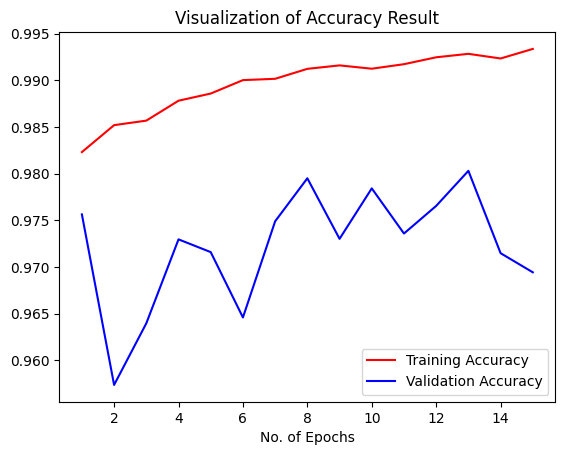

In [73]:
epochs = range(1, len(training_history.history['accuracy']) + 1)
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

## Some other metrics for model evaluation

In [74]:
class_name = validation_set.class_names

In [75]:
test_set = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\SRV\Projeto_Agrcultura_De_Precisao\Plant_Disease_Prediction\dataset\New Plant Diseases Dataset(Augmented)\valid",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=1,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)


Found 17572 files belonging to 38 classes.


In [76]:
y_pred = cnn.predict(test_set)
predicted_categories = tf.argmax(y_pred, axis=1)

17572/17572 ━━━━━━━━━━━━━━━━━━━━ 433s 25ms/step


In [77]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = tf.argmax(true_categories, axis=1)

In [78]:
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], shape=(17572,))>

In [79]:
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], shape=(17572,))>

In [80]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(Y_true,predicted_categories)

In [81]:
# Precision Recall Fscore
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.94      0.98      0.96       504
                                 Apple___Black_rot       1.00      0.97      0.98       497
                          Apple___Cedar_apple_rust       0.99      1.00      0.99       440
                                   Apple___healthy       0.98      0.92      0.95       502
                               Blueberry___healthy       0.99      0.97      0.98       454
          Cherry_(including_sour)___Powdery_mildew       0.99      0.99      0.99       421
                 Cherry_(including_sour)___healthy       0.98      0.98      0.98       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.94      0.92      0.93       410
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       477
               Corn_(maize)___Northern_Leaf_Blight       0.93      0.96      0.

### Confusion Matrix Visualization

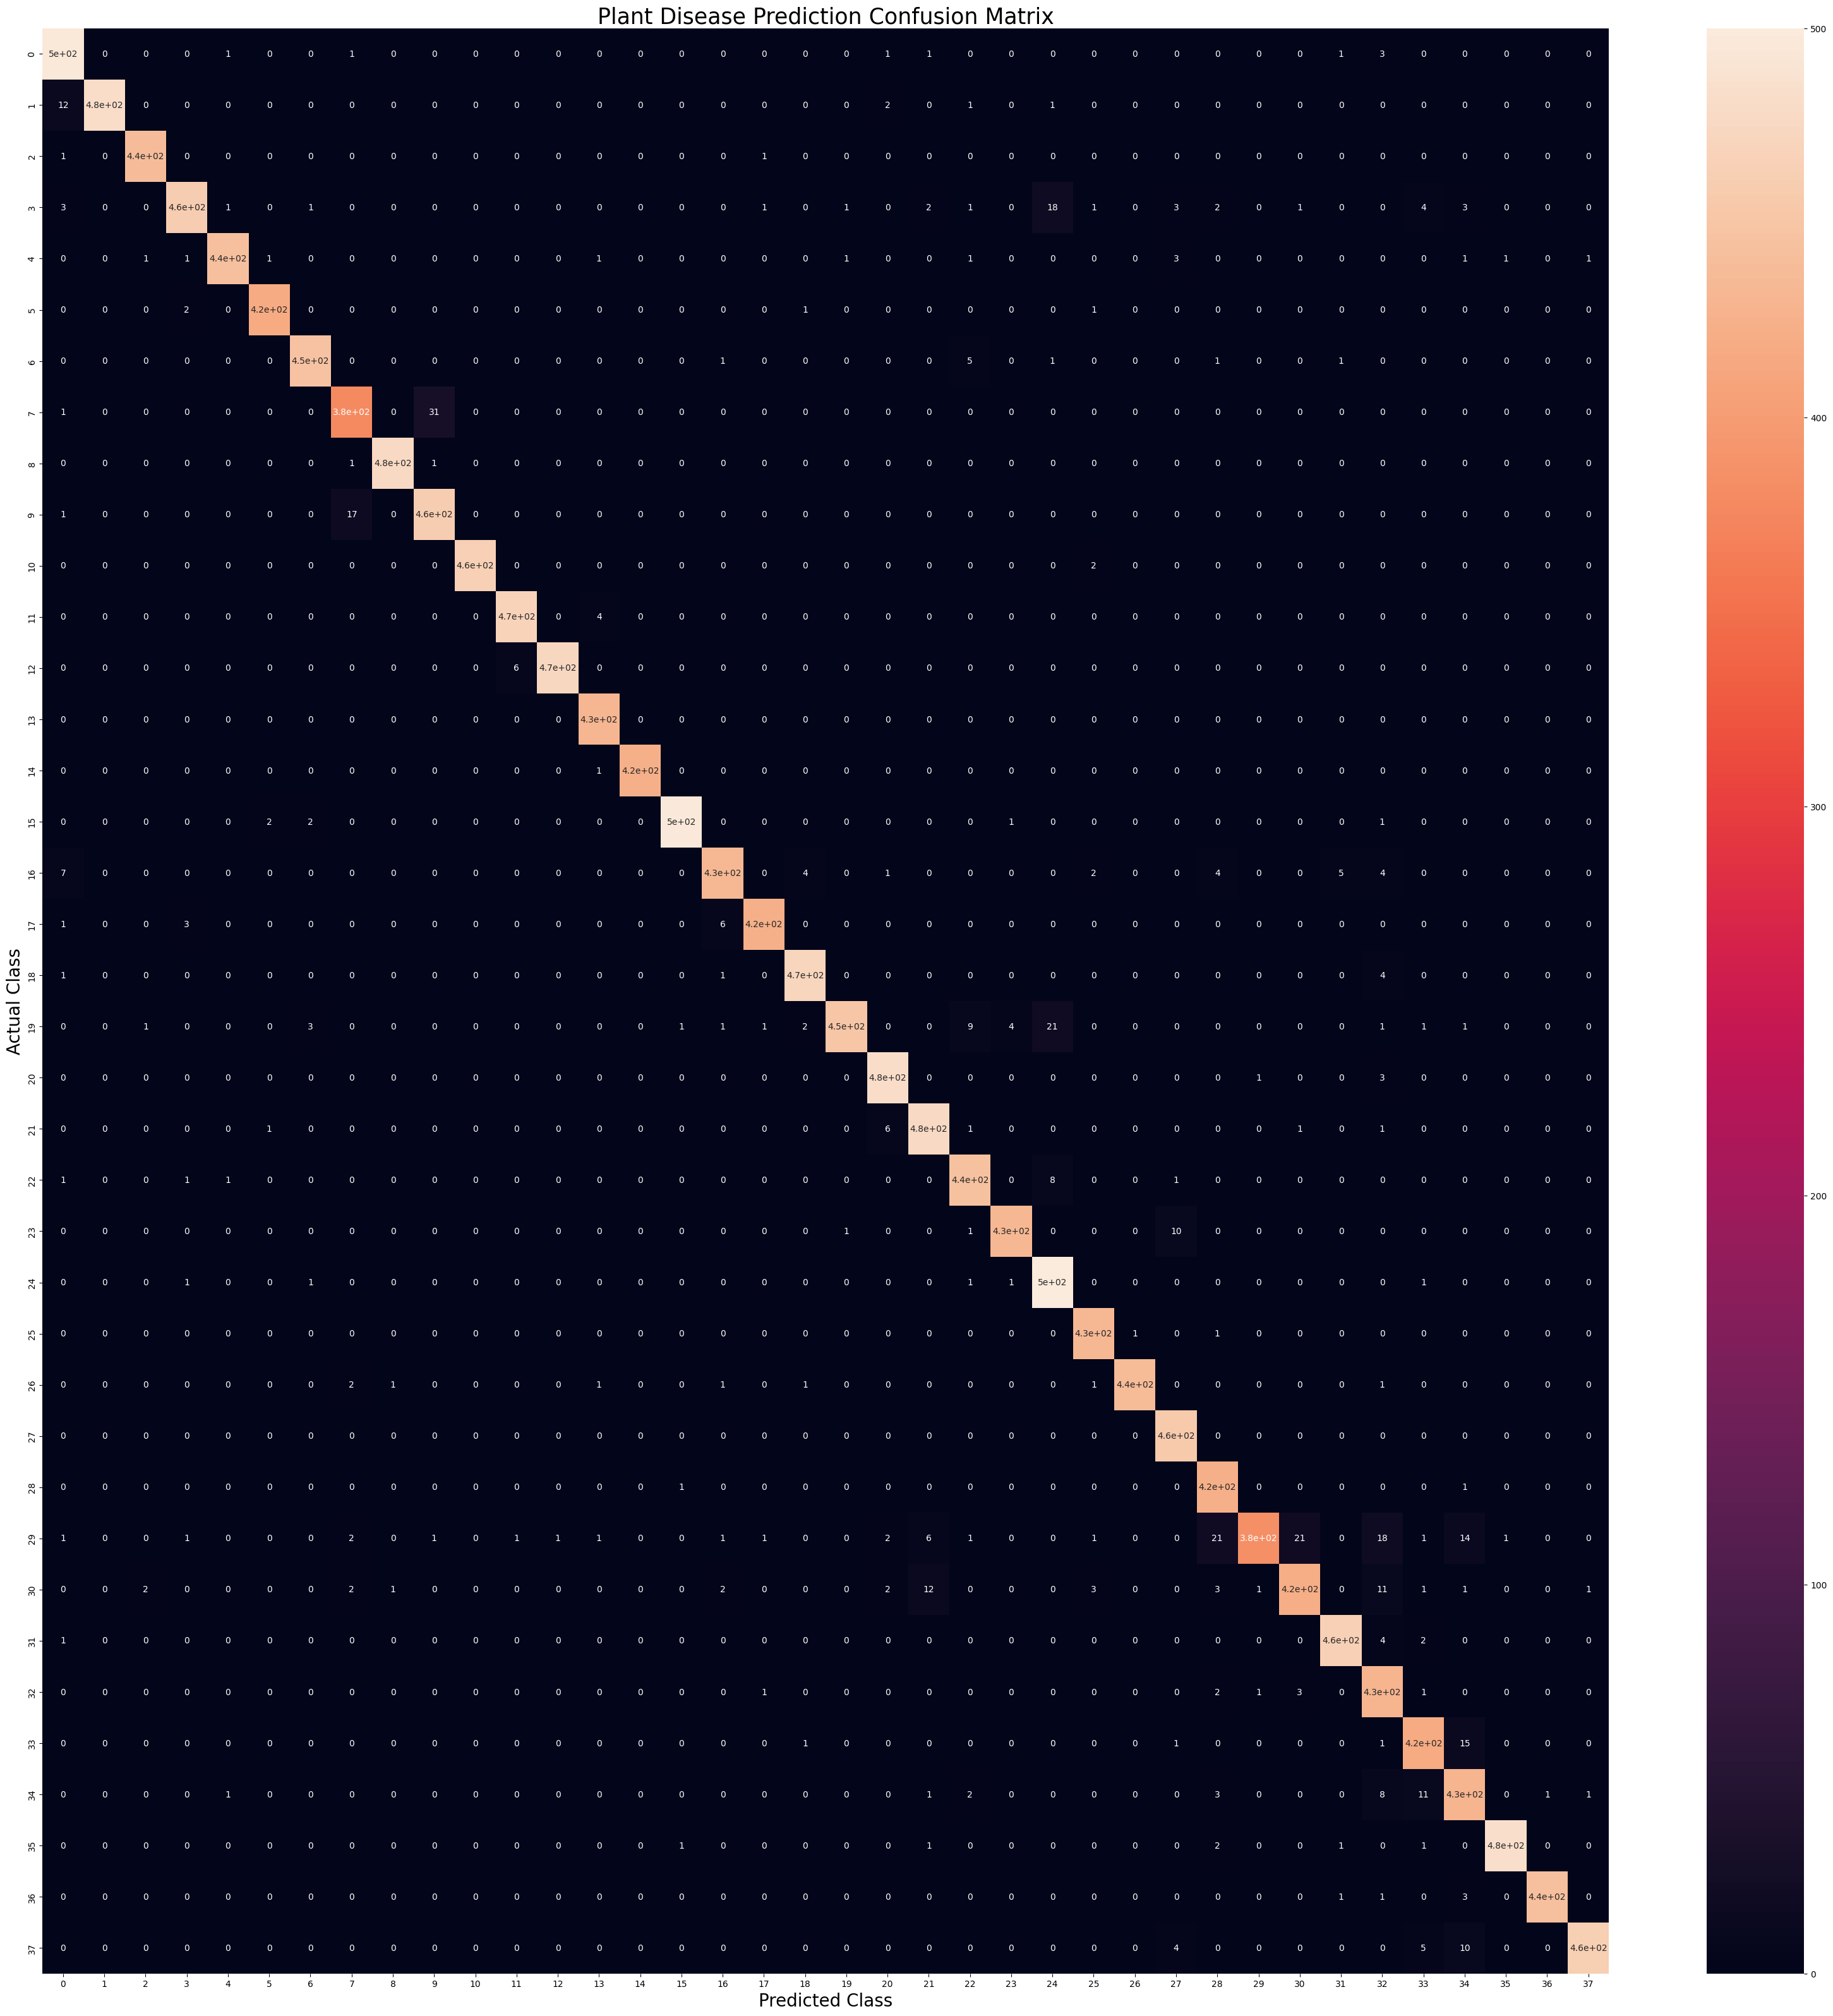

In [82]:
plt.figure(figsize=(40, 40))
sns.heatmap(cm,annot=True,annot_kws={"size": 10})

plt.xlabel('Predicted Class',fontsize = 20)
plt.ylabel('Actual Class',fontsize = 20)
plt.title('Plant Disease Prediction Confusion Matrix',fontsize = 25)
plt.show()